In [ ]:
# Load a saved run; standard reports and saved figures belong to cc_plot.py.
import sys
from pathlib import Path

import numpy as np

REPO_DIR = Path.cwd().parent
sys.path.insert(0, str(REPO_DIR / "src"))

from traffic_flow.results.io import load_runs
from traffic_flow.config import CalRef, CalSource
from traffic_flow.pipeline import simulate_scenario
from traffic_flow.results.plots import Plotter

matches = load_runs(
    "i24", "11_30",
    calibration=CalRef(CalSource.FIXED_RAMPS),
    study=None,
    where=lambda config: all([
        config.speed_lb == 0,
        config.init_fixed == 150.0
    ])
)
assert len(matches) == 1, "Expected one run, found {len(matches)}. Refine the selection."
saved = matches[0]
spec, traffic = saved.scenario.spec, saved.scenario.traffic

# Initial states are already selected; align the boundary inputs as before.
start_time_step = int(spec.start_time / spec.time_step)
traffic = traffic._replace(
    inflow=traffic.inflow[start_time_step:],
    downstream_density=traffic.downstream_density[start_time_step:],
)
v_data = traffic.velocity
# Preserve measured inflow and the unrestricted baseline (not the saved MPC baseline).
v_sim = simulate_scenario(
    traffic, saved.params, T=spec.time_step, l=spec.L, real_data=True,
).velocity[:-1]

# Preserve the speed substitution used by the checkpoint simulations.
optimal_vsl = np.where(
    saved.optimization.vsl > saved.params["v_free"], 150, saved.optimization.vsl,
)


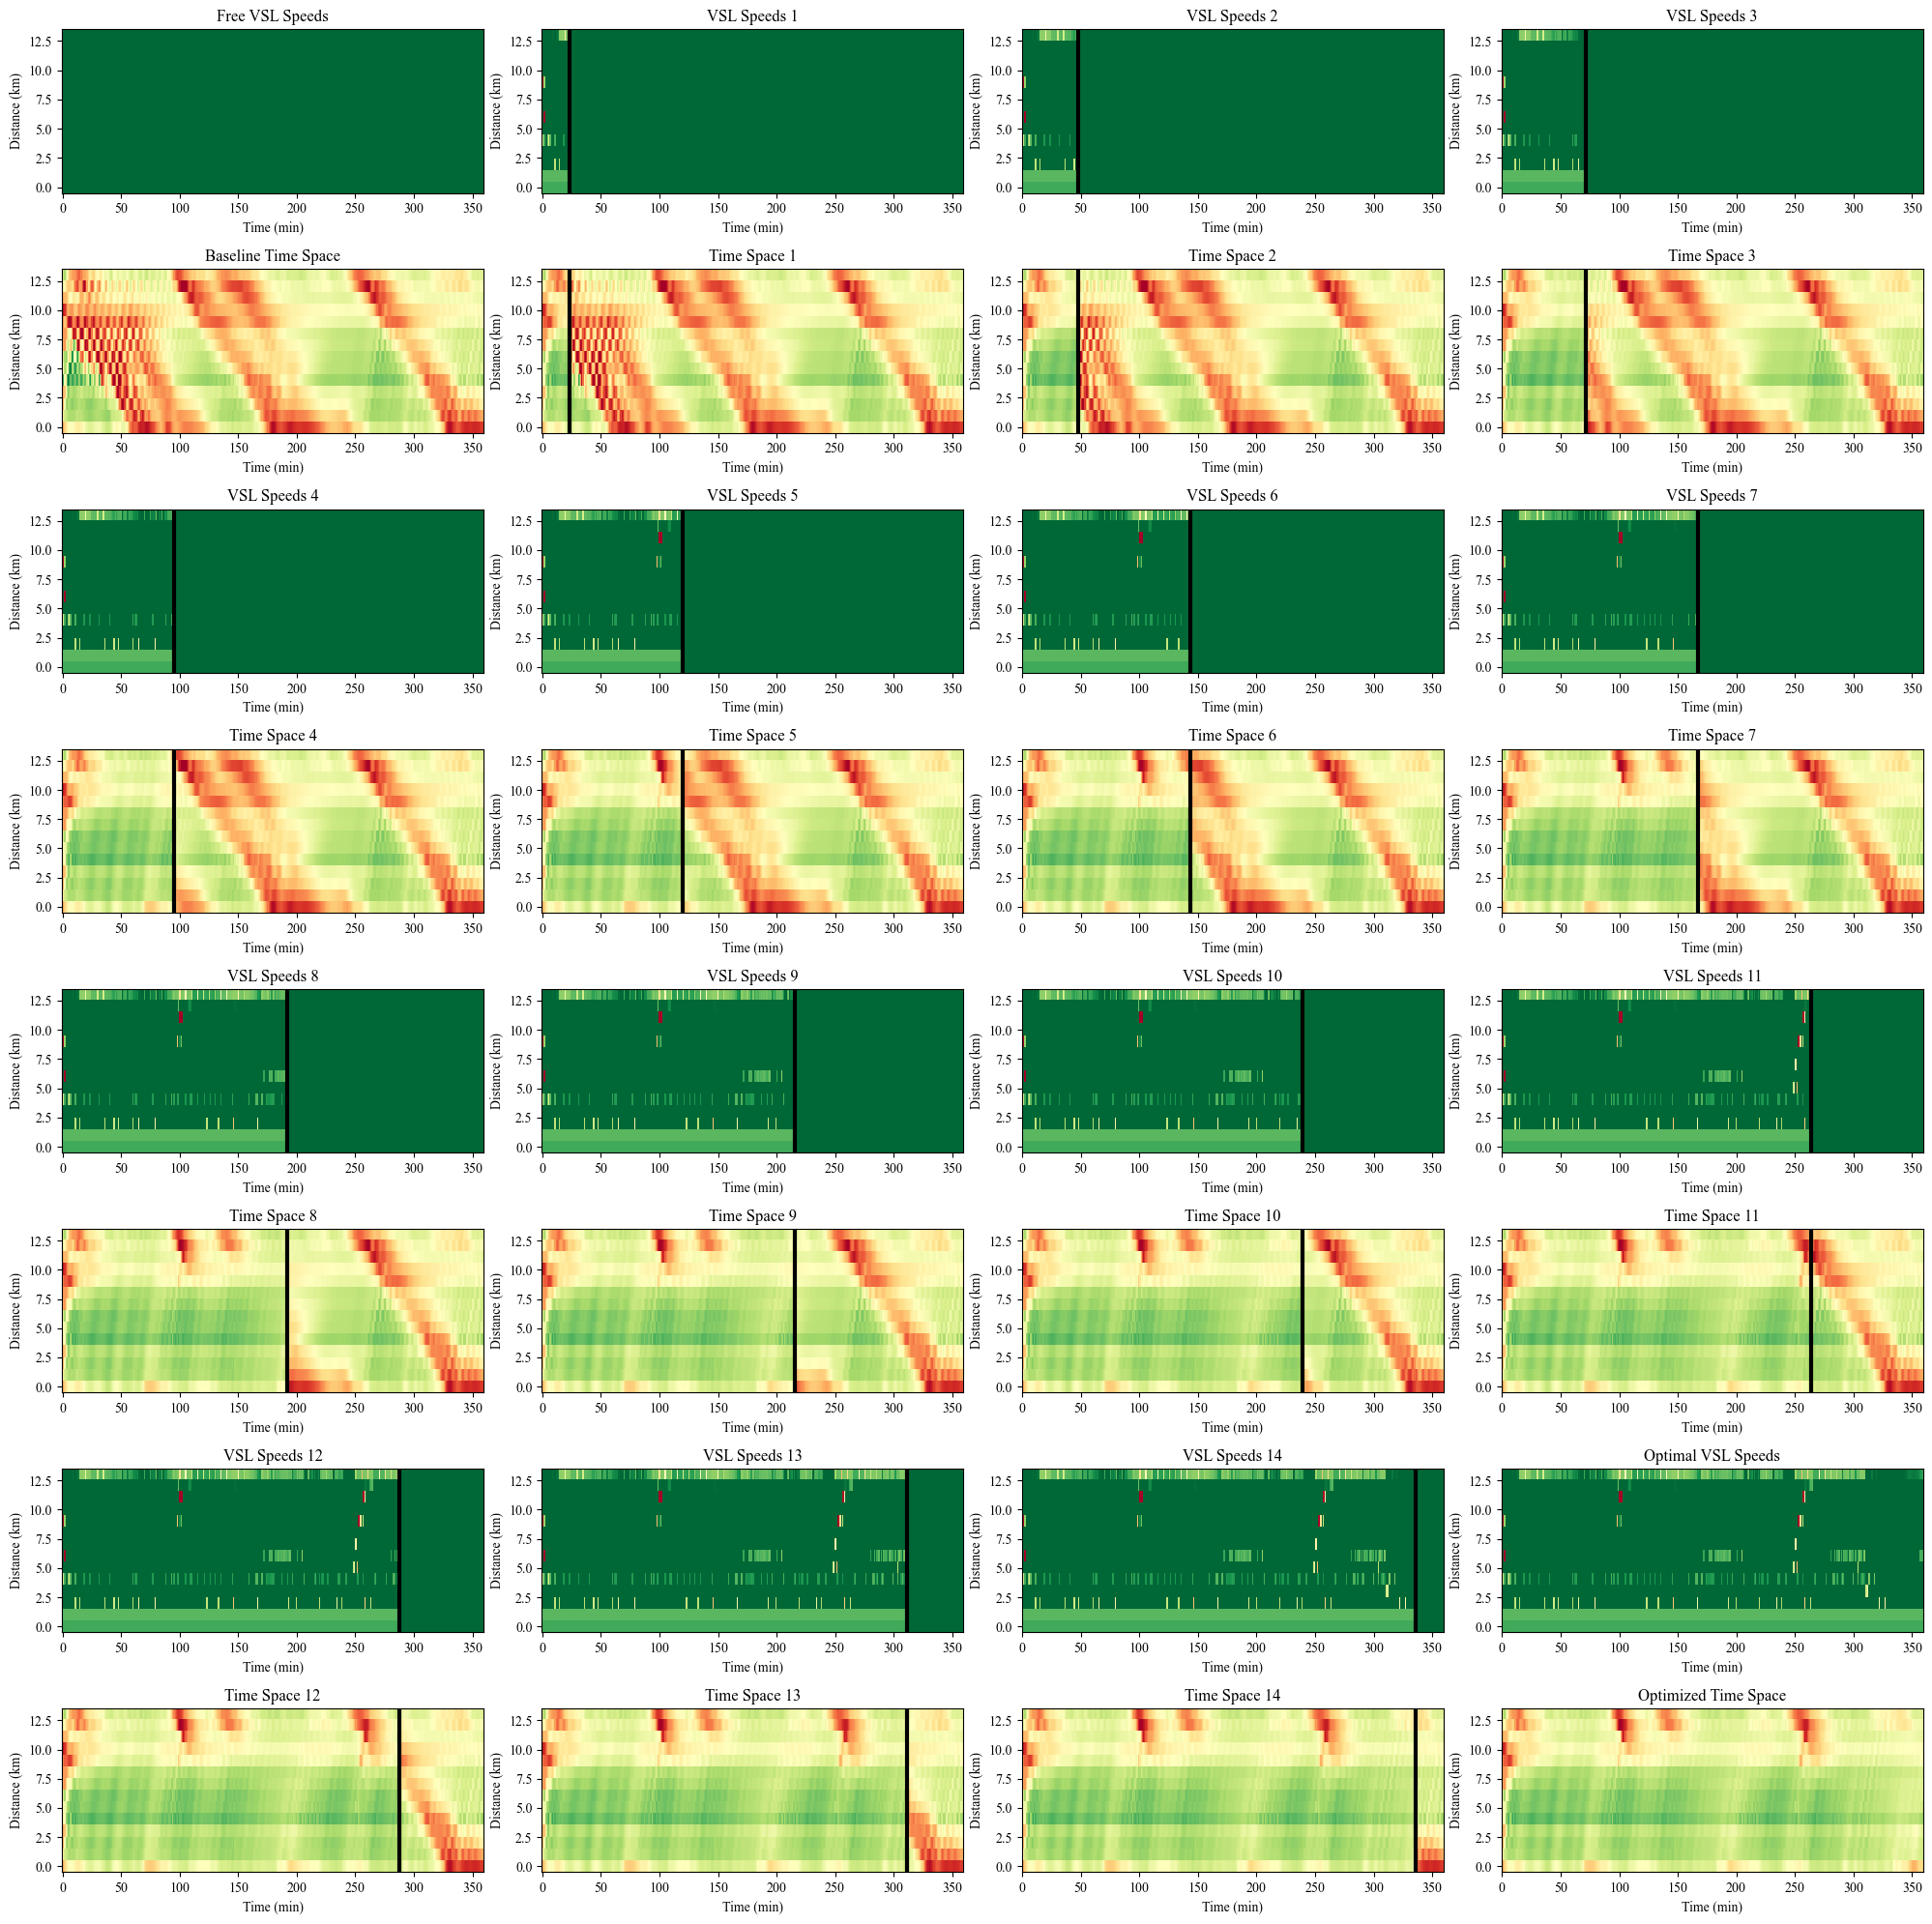

In [ ]:
CHECKPOINTS = 16
BATCHES = 4
PER_BATCH = CHECKPOINTS//BATCHES

times = np.rint(np.linspace(0,len(optimal_vsl),CHECKPOINTS)).astype(int)

vsls, v_s = [], []

for t in times:
    vsl = np.full_like(optimal_vsl, 150)
    vsl[:t] = optimal_vsl[:t]
    vsls.append(vsl)
    v_s.append(
        simulate_scenario(traffic, saved.params, T=spec.time_step, l=spec.L, vsl=vsl, real_data=True).velocity
    )

from matplotlib import colormaps

cmap = colormaps["RdYlGn"].copy()
cmap.set_bad("black")
vmax = max(v_data.max(),v_sim.max())

p = Plotter(2*BATCHES,PER_BATCH,figsize=(5*PER_BATCH,5*BATCHES))

for k,(vsl,velocity,t) in enumerate(zip(vsls,v_s,times)):
    b,i = divmod(k,PER_BATCH)

    plots = [
        (2*b*PER_BATCH+i,vsl,"VSL Speeds","Free VSL Speeds","Optimal VSL Speeds"),
        ((2*b+1)*PER_BATCH+i,velocity,"Time Space","Baseline Time Space","Optimized Time Space"),
    ]

    for j, data, name, first, last in plots:
        x = (vsls[0] if name=="VSL Speeds" else v_sim).copy()
        x[:t] = data[:t]
        p[j].imshow(x.T, cmap=cmap, aspect="auto", interpolation="none", vmin=0,vmax=vmax)
        if 0<t<len(x): p[j].axvline(t-.5,color="black",linewidth=3)
        p[j] = {"title": first if k==0 else last if k==CHECKPOINTS-1 else f"{name} {k}",
            "xlabel": "Time (min)", "ylabel": "Distance (km)"}
        p[j].invert_yaxis()

p.show()